In [4]:
# Cell 1: Imports and load news data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
print("Shape:", df.shape)
df.head()

Shape: (1407328, 6)


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


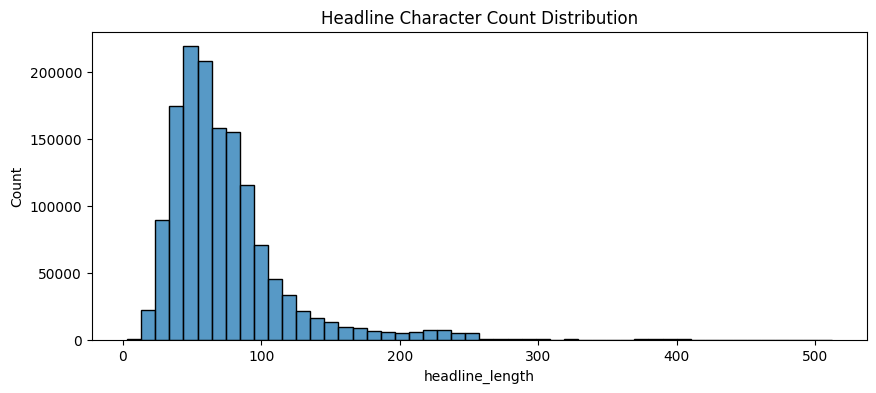

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


In [5]:
# Cell 2: Headline length distribution
df['headline_length'] = df['headline'].str.len()
plt.figure(figsize=(10,4))
sns.histplot(df['headline_length'], bins=50)
plt.title('Headline Character Count Distribution')
plt.show()
print(df['headline_length'].describe())

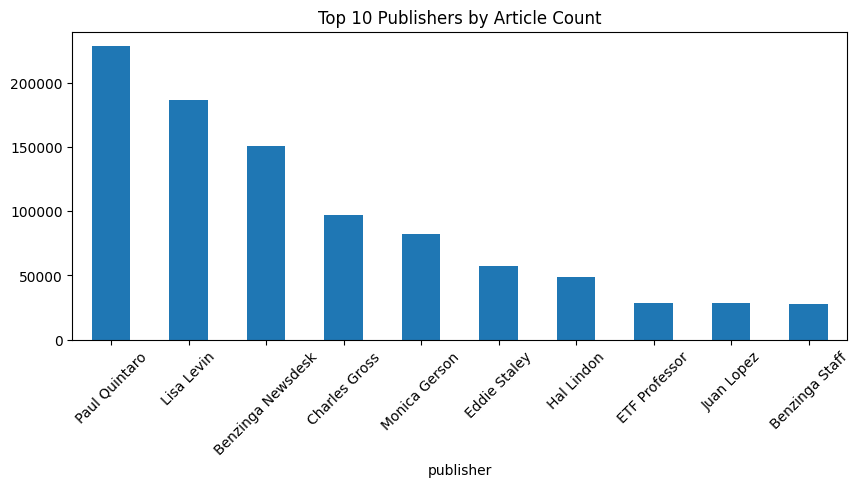

In [6]:
# Cell 3: Top 10 publishers
top_pubs = df['publisher'].value_counts().head(10)
plt.figure(figsize=(10,4))
top_pubs.plot(kind='bar')
plt.title('Top 10 Publishers by Article Count')
plt.xticks(rotation=45)
plt.show()

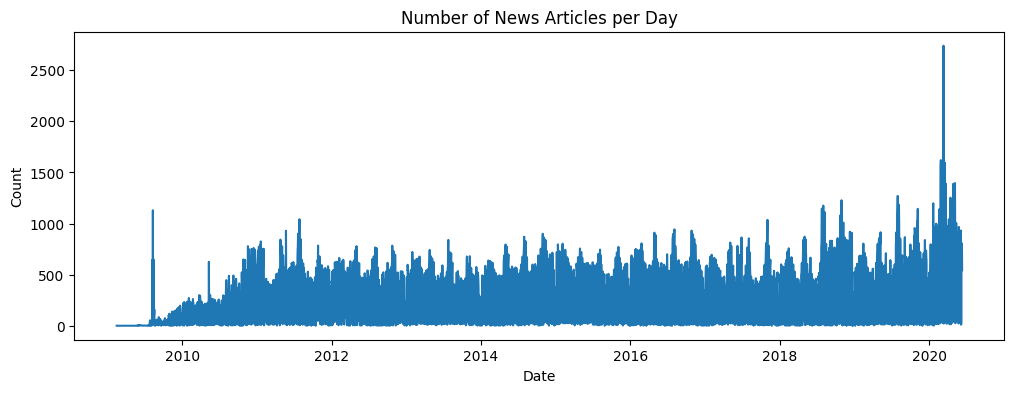

In [12]:
# Cell 4: Clean date column by removing timezone offsets, then convert
df['date_clean'] = df['date'].str.replace(r'[+-]\d{2}:\d{2}$', '', regex=True)
df['date'] = pd.to_datetime(df['date_clean'])
daily_counts = df.groupby(df['date'].dt.date).size()
plt.figure(figsize=(12,4))
daily_counts.plot()
plt.title('Number of News Articles per Day')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

In [13]:
# Cell 5: Top 20 keywords from headlines
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=20, stop_words='english')
X = vectorizer.fit_transform(df['headline'])
keywords = vectorizer.get_feature_names_out()
print("Top 20 keywords:", keywords)

Top 20 keywords: ['announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est' 'market'
 'mid' 'price' 'pt' 'raises' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']


In [14]:
import os
csv_files = [f for f in os.listdir('../data/raw') if f.endswith('.csv') and f != 'raw_analyst_rating.csv']
print("Stock CSV files:", csv_files)

Stock CSV files: ['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv', 'raw_analyst_ratings.csv']


In [15]:
# Cell 6: Load stock data and compute indicators (using AAPL as example)
stock_file = 'AAPL.csv'   
stock = pd.read_csv(f'../data/raw/{stock_file}', parse_dates=['Date'])
stock.set_index('Date', inplace=True)
stock.sort_index(inplace=True)

# Simple Moving Averages (20 and 50 days)
stock['SMA_20'] = stock['Close'].rolling(window=20).mean()
stock['SMA_50'] = stock['Close'].rolling(window=50).mean()

# Relative Strength Index (RSI - 14 days)
delta = stock['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
stock['RSI_14'] = 100 - (100 / (1 + rs))

# MACD (12,26,9)
ema12 = stock['Close'].ewm(span=12, adjust=False).mean()
ema26 = stock['Close'].ewm(span=26, adjust=False).mean()
stock['MACD'] = ema12 - ema26
stock['MACD_signal'] = stock['MACD'].ewm(span=9, adjust=False).mean()
stock['MACD_hist'] = stock['MACD'] - stock['MACD_signal']

stock.head()

,Close,High,Low,Open,Volume,SMA_20,SMA_50,RSI_14,MACD,MACD_signal,MACD_hist
Date,,,,,,,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN,NaN,0.000000,0.000000,0.000000
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,NaN,NaN,0.009163,0.001833,0.007331
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,NaN,NaN,0.012506,0.003967,0.008538
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,NaN,NaN,0.010173,0.005208,0.004965
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,NaN,NaN,0.012273,0.006621,0.005651


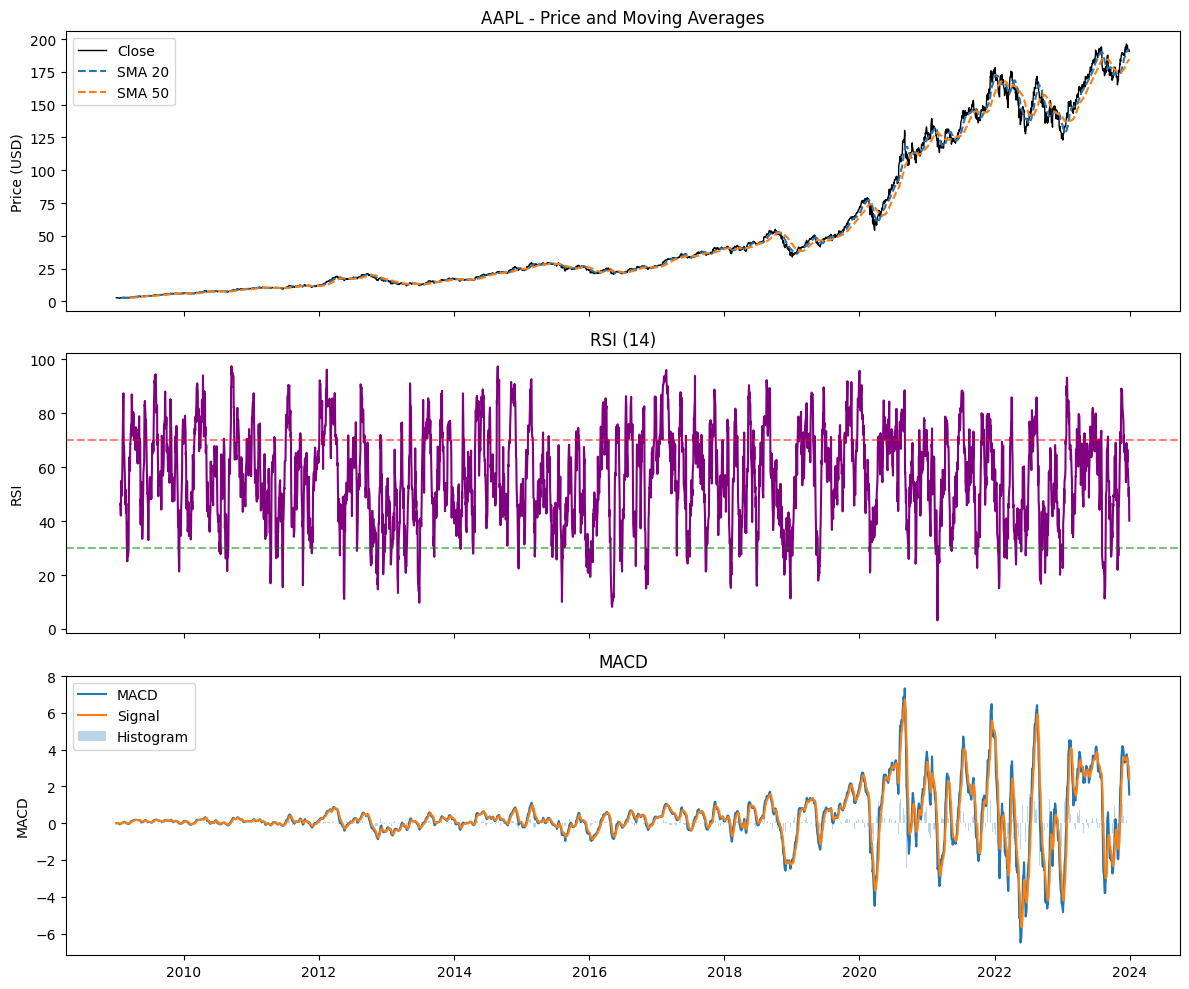

In [16]:
# Cell 7: Plot price with moving averages, RSI, and MACD
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Price and MAs
ax1.plot(stock.index, stock['Close'], label='Close', color='black', linewidth=1)
ax1.plot(stock.index, stock['SMA_20'], label='SMA 20', linestyle='--')
ax1.plot(stock.index, stock['SMA_50'], label='SMA 50', linestyle='--')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.set_title('AAPL - Price and Moving Averages')

# RSI
ax2.plot(stock.index, stock['RSI_14'], color='purple')
ax2.axhline(70, linestyle='--', color='red', alpha=0.5)
ax2.axhline(30, linestyle='--', color='green', alpha=0.5)
ax2.set_ylabel('RSI')
ax2.set_title('RSI (14)')

# MACD
ax3.plot(stock.index, stock['MACD'], label='MACD')
ax3.plot(stock.index, stock['MACD_signal'], label='Signal')
ax3.bar(stock.index, stock['MACD_hist'], label='Histogram', alpha=0.3, width=0.8)
ax3.set_ylabel('MACD')
ax3.legend()
ax3.set_title('MACD')

plt.tight_layout()
plt.show()

In [25]:
macd_positive = (stock['MACD_hist'] > 0)
if macd_positive.any():
    first_positive = stock.index[macd_positive][0]
    print("First positive MACD histogram on:", first_positive.date())
else:
    print("Never positive.")

First positive MACD histogram on: 2009-01-05


In [21]:
from sklearn.decomposition import LatentDirichletAllocation

# Create document-term matrix with more features
vectorizer_lda = CountVectorizer(max_features=1000, stop_words='english', max_df=0.9, min_df=5)
dtm = vectorizer_lda.fit_transform(df['headline'])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

feature_names = vectorizer_lda.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx+1}: {', '.join(top_words)}")

KeyboardInterrupt: 